# Proyecto Final – Econometría II (Machine Learning)  
## Predicción de Ventas Semanales de Walmart

**Autor:** Jonathan Amado  
**Programa:** Maestría en Investigación de Operaciones – Universidad Galileo  
**Curso:** Econometría II – Machine Learning  
**Fecha:** 24 de junio de 2025  

---

### Introducción  

En esta notebook se desarrolla el proyecto final del curso, cuyo objetivo es **construir y comparar diversos modelos de regresión** capaces de pronosticar las ventas semanales de las tiendas Walmart a partir de variables económicas (temperatura, precio del combustible, CPI, desempleo) y temporales (fecha, feriados, etc.).  

El flujo de trabajo incluye:  

1. **Exploratory Data Analysis (EDA)** para comprender la estructura y distribución de los datos.  
2. **Ingeniería de características** (limpieza, imputación, codificación, escalado) dentro de pipelines reproducibles.  
3. **Entrenamiento y ajuste** de modelos clásicos (regresión lineal, SVR, árboles, ensambles, KNN) y redes neuronales.  
4. **Evaluación comparativa** mediante RMSE y selección del modelo campeón.  
5. **Conclusiones** y recomendaciones basadas en los hallazgos.  

Todos los pasos están documentados y las ejecuciones son reproducibles mediante los scripts y archivos presentes en este repositorio.

### Cargamos el Dataset

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

# Cargar el CSV (asumiendo que está en la misma carpeta que la notebook)
df = pd.read_csv("Walmart.csv", parse_dates=["Date"])

# Vista rápida
display(df.head())
display(df.info())


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


None

## 1. Análisis Exploratorio de Datos (EDA)

En esta primera sección examinaremos visual y descriptivamente el conjunto `Walmart.csv` para **entender la forma, dispersión y relaciones iniciales** de las variables antes de construir modelos.  
A grandes rasgos:

- Veremos la distribución de las variables continuas mediante gráficas de densidad.  
- Exploraremos las variables categóricas (`Holiday_Flag` y `Store`) con conteos y su impacto en `Weekly_Sales`.  
- Revisaremos la evolución temporal del target para detectar tendencias o estacionalidad.  
- Analizaremos la correlación entre métricas económicas y las ventas.  

Este diagnóstico preliminar nos permitirá formular hipótesis y anticipar los desafíos de modelado.


### 1.a  Gráficas de densidad – variables continuas

A continuación se visualiza la distribución de `Weekly_Sales`, `Temperature`, `Fuel_Price`, `CPI` y `Unemployment`.  
El objetivo es identificar asimetrías, colas, multimodalidad y posibles valores atípicos que puedan condicionar el modelado.


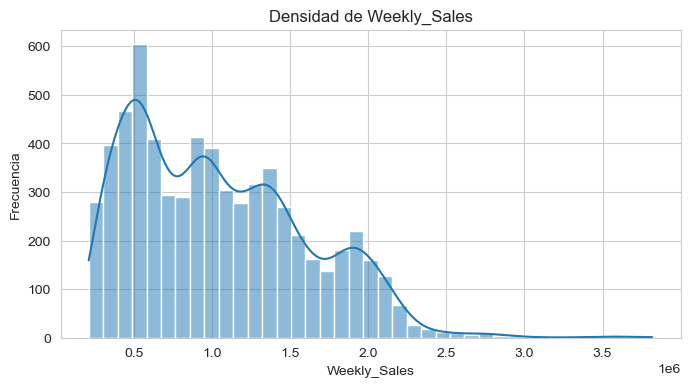

In [25]:
plt.figure()
sns.histplot(df["Weekly_Sales"].dropna(), kde=True)
plt.title("Densidad de Weekly_Sales")
plt.xlabel("Weekly_Sales")
plt.ylabel("Frecuencia")
plt.show()

La distribución es asimétrica a la derecha: la mayoría de las semanas se concentran por debajo de 1.5 M, pero existe una cola que llega a ~3.8 M. Esto apunta a picos de demanda, quizá en temporadas altas o eventos promocionales.

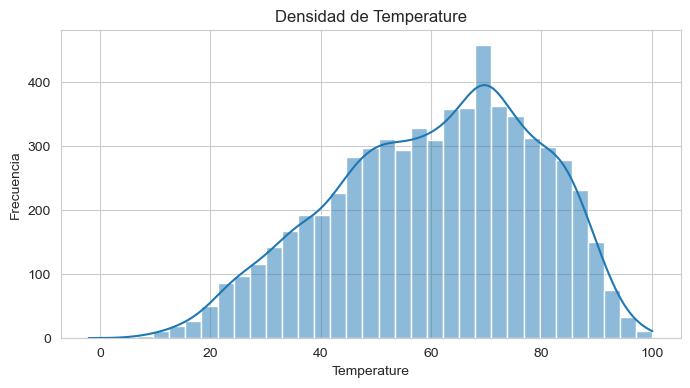

In [31]:
plt.figure()
sns.histplot(df["Temperature"].dropna(), kde=True)
plt.title("Densidad de Temperature")
plt.xlabel("Temperature")
plt.ylabel("Frecuencia")
plt.show()

Ligera asimetría a la izquierda; los valores se agrupan entre 40 °F y 80 °F, con pocos extremos fríos o calurosos. No se observan outliers severos.

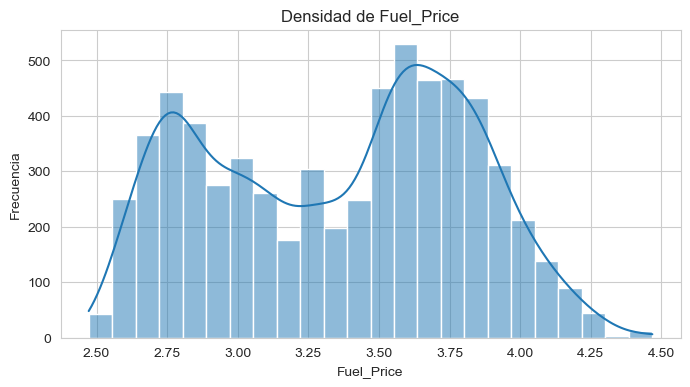

In [38]:
plt.figure()
sns.histplot(df["Fuel_Price"].dropna(), kde=True)
plt.title("Densidad de Fuel_Price")
plt.xlabel("Fuel_Price")
plt.ylabel("Frecuencia")
plt.show()

Distribución casi simétrica centrada en torno a 3.3 USD/galón; la variabilidad es baja y no hay outliers pronunciados.

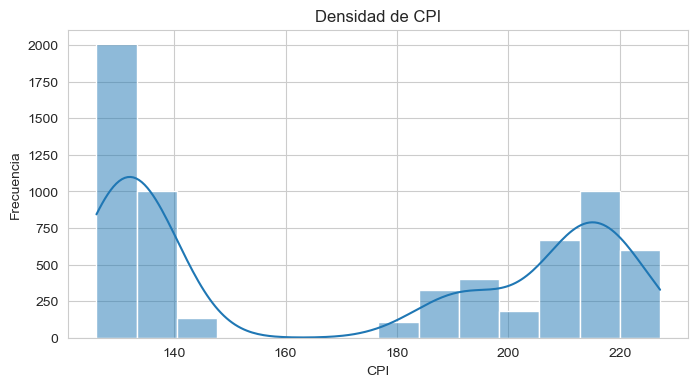

In [128]:
plt.figure()
sns.histplot(df["CPI"].dropna(), kde=True)
plt.title("Densidad de CPI")
plt.xlabel("CPI")
plt.ylabel("Frecuencia")
plt.show()

🔎 **:** Aproximadamente normal con leve sesgo a la derecha; la mayoría de los valores está entre 130 y 220, sin extremos marcados.

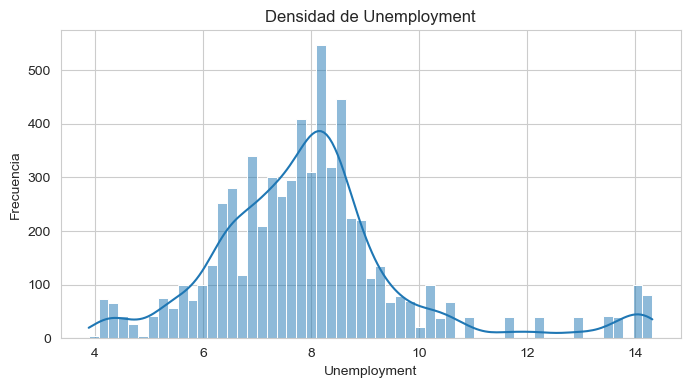

In [132]:
plt.figure()
sns.histplot(df["Unemployment"].dropna(), kde=True)
plt.title("Densidad de Unemployment")
plt.xlabel("Unemployment")
plt.ylabel("Frecuencia")
plt.show()

Claramente sesgada a la derecha; la mayoría se sitúa entre 4 % y 9 %, pero hay una cola que llega a ~14 %, indicando periodos de mayor desempleo que podrían afectar las ventas.

### 1.b  Variables categóricas: `Holiday_Flag` y `Store`

En este apartado se exploran las variables categóricas del conjunto de datos:

1. **Conteo de clases** – gráfico de barras para visualizar la frecuencia de cada categoría.  
2. **Relación con `Weekly_Sales`** – boxplot para observar cómo varía la distribución del target según cada categoría.

Se incluye un comentario breve después de cada figura para resaltar los hallazgos clave.


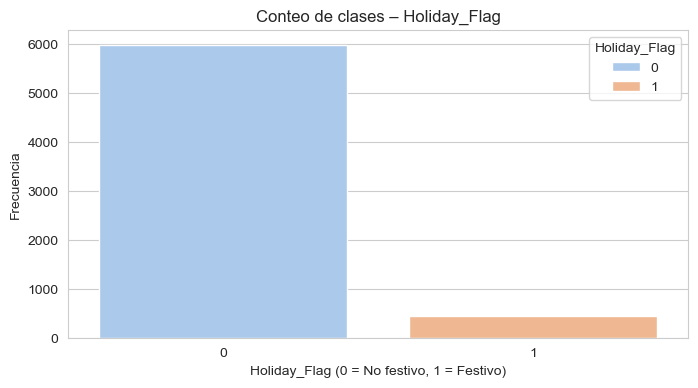

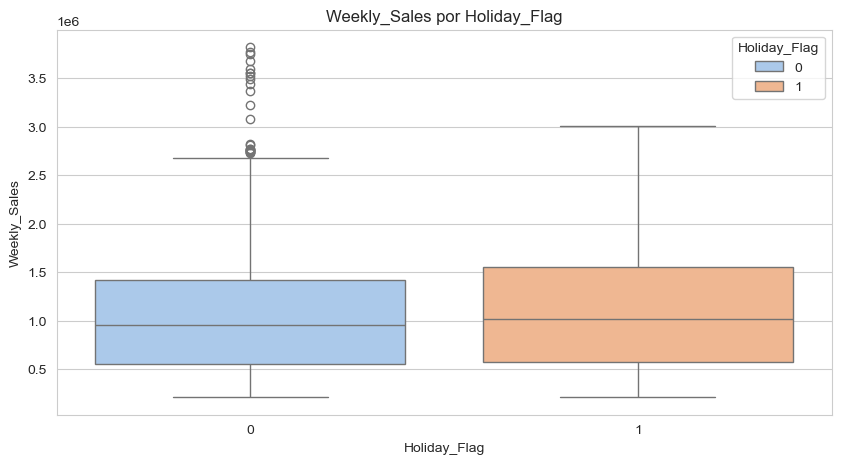

In [134]:
# ------------------------------
# Variable 1: Holiday_Flag
# ------------------------------
plt.figure()
sns.countplot(x="Holiday_Flag", hue="Holiday_Flag", data=df, palette="pastel")
plt.title("Conteo de clases – Holiday_Flag")
plt.xlabel("Holiday_Flag (0 = No festivo, 1 = Festivo)")
plt.ylabel("Frecuencia")
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(x="Holiday_Flag", hue="Holiday_Flag", y="Weekly_Sales", data=df, palette="pastel")
plt.title("Weekly_Sales por Holiday_Flag")
plt.xlabel("Holiday_Flag")
plt.ylabel("Weekly_Sales")
plt.show()


La mayoría de las observaciones corresponde a semanas sin festivo (`0`), con un número mucho menor de semanas festivas (`1`). El boxplot muestra que, aunque el rango intercuartílico es parecido, las semanas festivas presentan una **mediana ligeramente superior** y valores máximos más altos. Esto sugiere que los festivos pueden incrementar las ventas, pero el efecto no es uniforme en todas las tiendas.


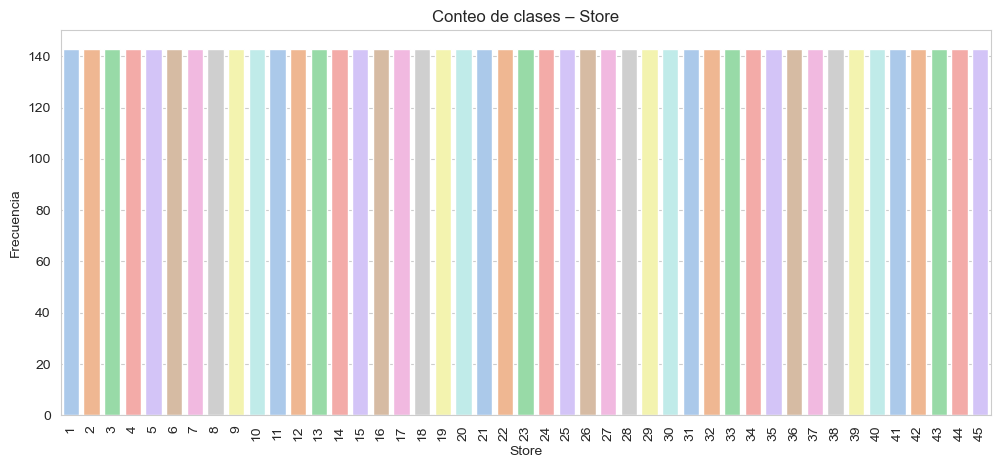

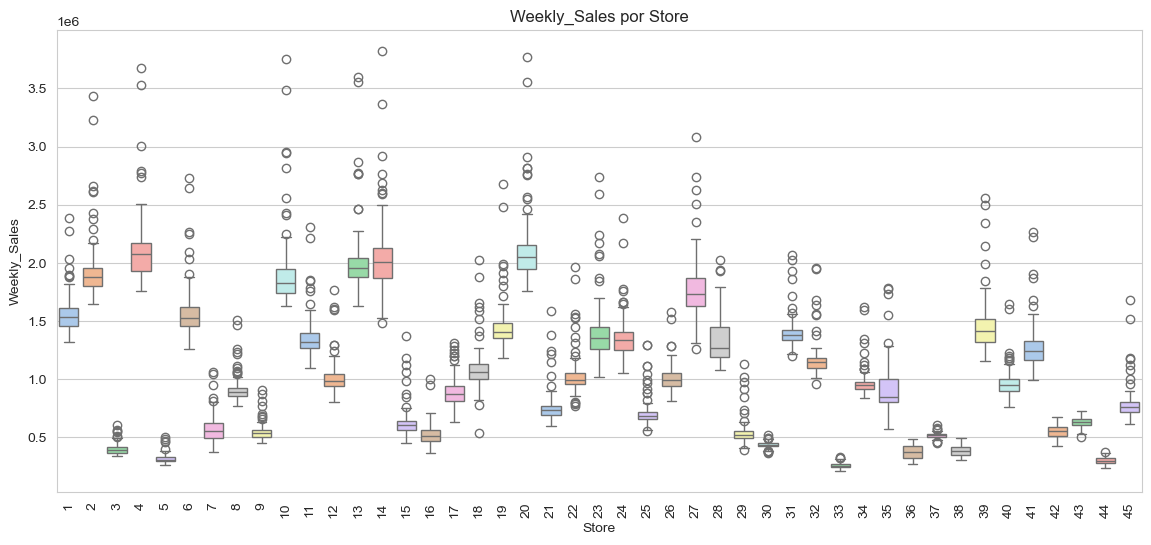

In [136]:
# ------------------------------
# Variable 2: Store
# ------------------------------
plt.figure(figsize=(12,5))
sns.countplot(x="Store", data=df, palette="pastel")
plt.title("Conteo de clases – Store")
plt.xlabel("Store")
plt.ylabel("Frecuencia")
plt.xticks(rotation=90)
plt.show()

plt.figure(figsize=(14,6))
sns.boxplot(x="Store", y="Weekly_Sales", data=df, palette="pastel")
plt.title("Weekly_Sales por Store")
plt.xlabel("Store")
plt.ylabel("Weekly_Sales")
plt.xticks(rotation=90)
plt.show()

El gráfico de barras muestra que todas las tiendas tienen el mismo número de registros, lo cual confirma que el dataset está perfectamente balanceado en cuanto a observaciones por tienda. Sin embargo, el boxplot revela **variaciones sustanciales en la mediana y la dispersión de `Weekly_Sales` entre tiendas**. Esto sugiere que, aun con la misma cantidad de semanas registradas, factores como la ubicación, el tamaño o la base de clientes influyen en el nivel de ventas. Algunas tiendas presentan colas más largas y valores máximos mayores, lo que podría asociarse a eventos promocionales particulares o características del mercado local.



<Axes: title={'center': 'Promedio semanal de ventas por tienda'}, xlabel='Store'>

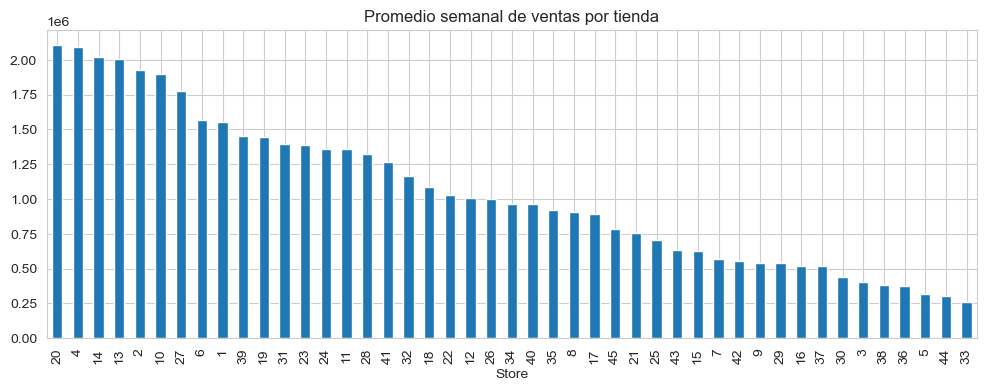

In [139]:
store_avg = df.groupby("Store")["Weekly_Sales"].mean().sort_values(ascending=False)
store_avg.plot(kind="bar", figsize=(12,4), title="Promedio semanal de ventas por tienda")
